# **Ballistic Coefficient and Initial Velocity Sweep**

**IMPORTS**

In [24]:
import numpy as np
from scipy.integrate import solve_ivp
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, LinearSegmentedColormap
import matplotlib.patches as mpatches
from datetime import datetime
from scipy.interpolate import interp1d
from joblib import Parallel, delayed

**GLOBAL MARS PARAMETERS**

In [25]:
mars_mu = 4.2828e13 #in m^3/s^2
mars_radius = 3396000.0 #in meters

**VEHICLE PARAMETERS**

In [26]:
vehicle_mass = 10000.0 #in kg
vehicle_lift_to_drag = 1.0 
vehicle_nose_radius = 3.5 #in meters

**ATMOSPHERE FUNCTION**

In [27]:
def mars_atmosphere_density(altitude):
    """
    Calculates the atmospheric density at a given altitude above Mars.

    Parameters
    ----------
    altitude : float
        Altitude above the Martian surface in meters.

    Returns
    -------
    float
        Atmospheric density in kg/m³.
    """

    if altitude >= 130000:

        return 0.0

    elif altitude >= 40000:

        return (3.7e-4 * np.exp(-1.371e-4 * (altitude - 40000)))

    elif altitude >= 20000:

        return (2.8e-3 * np.exp(-1.012e-4 * (altitude - 20000)))

    elif altitude >= 0:

        return (1.417e-2 * np.exp(-0.8109e-4 * altitude))

    else:
        # Below the surface.
        # Prevents None from ever being returned.
        return 0

**THERMAL FUNCTIONS**

**Radiative Heat Flux Correlations for Mars**

Below 6km/s Model

In [28]:
def mars_slow(V, rho, Rn):
    """
    Low-speed Mars radiative heating correlation (Eq. 7)

    Parameters
    ----------
    V : Freestream velocity [km/s]
    rho : Freestream density [kg/m^3]
    Rn : Effective nose radius [m]

    Returns
    -------
    q_rad : Radiative heat flux [W/m^2]
    """
    
    L = np.log(rho)

    f = (
        # Constant + first order
        -6.0539
        + 4.6540*V
        - 0.3880*L
        + 0.2274*Rn

        # Second order
        - 0.3080*V**2
        - 0.1430*V*L
        - 0.0914*V*Rn
        - 0.1584*L**2
        - 0.0856*L*Rn
        - 0.0573*Rn**2

        # Third order
        - 0.1212*V**3
        + 0.0935*V**2*L
        + 0.0371*V**2*Rn
        + 5.7929e-3*V*L**2
        - 7.4995e-4*V*Rn**2
        + 3.9562e-4*V*L*Rn
        - 9.3175e-3*L**3
        - 2.8918e-3*L**2*Rn
        + 4.0269e-3*L*Rn**2
        + 4.3082e-3*Rn**3

        # Fourth order
        + 0.0164*V**4
        - 6.6590e-3*V**3*L
        - 2.8111e-3*V**3*Rn
        + 1.0757e-3*V**2*L**2
        + 1.4478e-3*V**2*L*Rn
        + 2.9279e-4*V**2*Rn**2
        - 7.0553e-4*V*L**3
        - 2.0861e-4*V*Rn**3
        - 6.7496e-4*V*L**2*Rn
        - 7.5224e-4*V*L*Rn**2
        - 5.2606e-4*L**4
        - 3.4735e-4*L**3*Rn
        - 1.3343e-4*L**2*Rn**2
        - 8.5005e-5*L*Rn**3
        - 8.5250e-5*Rn**4
    )

    q_rad = np.exp(f)   
    return q_rad


Interpolation of F(V) Values for Earth and Mars Based on Emperical Data for Radiative Heat Flux

In [29]:
# Earth 
v_earth = np.array([9000, 9250, 9500, 9750,
    10000, 10250, 10500, 10750,
    11000, 11500, 12000, 12500,
    13000, 13500, 14000, 14500,
    15000, 15500, 16000])

f_earth = np.array([1.5, 4.3, 9.7, 19.5,
    35, 55, 81, 115,
    151, 238, 359, 495,
    660, 850, 1065, 1313,
    1550, 1780, 2040])

# Mars
v_mars = np.array([6000, 6150, 6300, 6500,
    6700, 6900, 7000, 7200,
    7400, 7600, 7800, 8000,
    8200, 8400, 8600, 8800,
    9000])

f_mars =np.array([0.2, 1.0, 1.95, 3.42,
    5.1, 7.1, 8.1, 10.2,
    12.5, 14.8, 17.1, 19.2,
    21.4, 24.1, 26.0, 28.9,
    32.8])

# Interpolation for f(v) values

f_interp = interp1d(v_earth, f_earth, kind='linear')
f_interp_mars = interp1d(v_mars, f_mars, kind='linear')

Between 6km/s and 9km/s Model

In [30]:
def mars_medium(V, rho, Rn):
    """
        Medium speed Mars radiative heating correlation
    
        Parameters
        ----------
        V : Freestream velocity [km/s]
        rho : Freestream density [kg/m^3]
        Rn : Effective nose radius [m]

        Returns
        -------
        q_rad : Radiative heat flux [W/m^2]
    """

    V_table = np.clip(V*1000, v_mars[0], v_mars[-1]) #Clips the table values to avoid extrapolation
    fmars = f_interp_mars(V_table)
    alpha = 2.35e4
    q_rad = alpha * (Rn ** 0.526) * (rho ** 1.19) * fmars
    return q_rad

Above 9km/s Model

In [31]:
def earth_fast(V, rho, Rn):
     
    """
    Fast-speed Earth radiative heating relation (Equivalent to Mars at that speed)
    
    Parameters
    ----------
    V : Freestream velocity [km/s]
    rho : Atmospheric density [kg/m^3]
    Rn : Effective nose radius [m]

    Returns
    -------
    q_rad : Radiative heat flux [W/cm^2]
    """

    V_table = np.clip(V*1000, v_earth[0], v_earth[-1]) #Clips the table values to avoid extrapolation
    fE = f_interp(V_table)
    alpha = 4.72e4
    q_rad = alpha * (Rn ** 0.47) * (rho ** 1.22) * fE
    return q_rad

**Convective Heat Flux Correlation for Mars**

In [32]:
def convective_heat_flux(V, rho, Rn):
    """
    Convective heat flux correlation (Sutton-Graves)

    Parameters
    ----------
    V : Freestream velocity [km/s]
    rho : Atmospheric density [kg/m^3]
    Rn : Effective nose radius [m]

    Returns
    -------
    q_conv : Convective heat flux [W/cm^2]
    """
    q_conv = 18.3 * np.sqrt(rho / Rn) * (V ** 3)
    return q_conv


**G-LOAD FUNCTION**

In [33]:
def g_load_func(altitude, velocity, vehicle_ballistic_coefficient):
    """
    G-load calculation based on the current altitude and velocity of the spacecraft.

    Parameters
    ----------
    altitude : Current altitude taken from altitude_trajectory array [km]
    velocity : Current velocity taken from velocity_trajectory array [km/s]

    Returns
    -------
    g_load : G-load experienced by the spacecraft [g's]
    """

    density = mars_atmosphere_density(altitude)
    drag_force = (0.5 * density * velocity**2 * vehicle_mass /vehicle_ballistic_coefficient)
    lift = (drag_force * vehicle_lift_to_drag)
    g_load = np.sqrt(drag_force**2 + lift**2) / (vehicle_mass * 9.80665)
    return g_load

**AEROCAPTURE SWEEP FUNCTION**

In [34]:
def run_aerocapture(vehicle_ballistic_coefficient, initial_velocity):
    """
    Simulates a complete Mars aerocapture maneuver using a three-phase
    predictive bank-angle guidance algorithm.

    The trajectory is divided into three guidance phases:
        1. Entry targeting to reach a 60 km reference altitude.
        2. Atmospheric glide to maintain the desired flight corridor.
        3. Exit targeting to achieve the desired post-aerocapture apoapsis.

    If the vehicle violates any flight constraints or a valid guidance
    solution cannot be found, the simulation terminates and returns None.
    Otherwise, the function returns the trajectory history and key
    performance metrics, including apoapsis altitude, circularization
    delta-V, peak heating rates, and maximum g-load.

    Parameters
    ----------
    vehicle_ballistic_coefficient : float
        Spacecraft ballistic coefficient in kg/m².

    initial_velocity : float
        Spacecraft velocity at atmospheric entry in m/s.

    Returns
    -------
    dict or None
        Dictionary containing trajectory history and performance metrics
        for a successful aerocapture, or None if the simulation fails.
    """


    # --------------------------------------------------------
    # SPACECRAFT EQUATIONS OF MOTION
    # --------------------------------------------------------
    def spacecraft_dynamics(time, state, bank_angle):
        """
        Computes Mars aerocapture equations of motion.

        State vector:
        [altitude, downrange, velocity, flight path angle, longitude angle]
        """

        altitude = state[0]
        downrange = state[1]
        velocity = state[2]
        gamma = state[3]
        theta = state[4]

        density = mars_atmosphere_density(altitude)

        radius = mars_radius + altitude

        gravity = mars_mu / radius**2

        drag_force = (0.5 * density * velocity**2 * vehicle_mass / vehicle_ballistic_coefficient)

        lift_force = drag_force * vehicle_lift_to_drag

        altitude_rate = velocity * np.sin(gamma)

        downrange_rate = (mars_radius / radius) * velocity * np.cos(gamma)

        velocity_rate = (-drag_force / vehicle_mass - gravity * np.sin(gamma))

        gamma_rate = ((lift_force * np.cos(bank_angle)) / (vehicle_mass * velocity) + ((velocity**2 / radius) - gravity) * np.cos(gamma) / velocity)

        theta_rate = (velocity * np.cos(gamma) / radius)

        return [
            altitude_rate,
            downrange_rate,
            velocity_rate,
            gamma_rate,
            theta_rate
        ]
    

    # --------------------------------------------------------
    # INITIAL CONDITIONS
    # --------------------------------------------------------
    initial_altitude = 130000.0 #m
    initial_downrange = 0.0     #m
    initial_gamma = np.radians(-11.0)  
    initial_theta = np.radians(0.0)
    initial_state = np.array([
        initial_altitude,
        initial_downrange,
        initial_velocity,
        initial_gamma,
        initial_theta
    ])


    # --------------------------------------------------------
    # SIMULATION HISTORY
    # --------------------------------------------------------
    trajectory_history = []

    trajectory_time_history = []

    trajectory_bank_history = []

    simulation_time = 0.0


    # Failure Flag
    failure = None


    # --------------------------------------------------------
    # STEP 1 CONTROL
    # --------------------------------------------------------

    print(
        f"Running beta={vehicle_ballistic_coefficient}, "
        f"velocity={initial_velocity}"
    )


    #Step 1 Parameters
    STEP1_TARGET_ALTITUDE = 60000.0          #m
    STEP1_ALTITUDE_TOLERANCE = 1000.0        #m
    STEP1_BANK_MIN = 0.0                     #deg
    STEP1_BANK_MAX = 180.0                   #deg
    STEP1_NUMBER_OF_BANKS = 37
    STEP1_MAX_BANK_RATE = np.radians(10.0)
    STEP1_GUIDANCE_TIMESTEP = 2.0


    # Step 1 Event
    # Detect descending crossing of target altitude
    def step1_altitude_event(time, state, bank_angle):
        return state[0] - STEP1_TARGET_ALTITUDE


    step1_altitude_event.direction = -1
    step1_altitude_event.terminal = True


    # Predict to 60 km (defined target altitude)
    def step1_predict_to_target(state_initial, bank_angle):
        prediction_solution = solve_ivp(
            spacecraft_dynamics,
            [0.0, 2000.0],
            state_initial,
            args=(bank_angle,),
            events=step1_altitude_event,
            max_step=2.0,
            rtol=1e-8,
            atol=1e-8
        )

        if len(prediction_solution.t_events[0]) == 0:
            return None

        return prediction_solution.y_events[0][0]


    # Find Best Bank Angle
    # Test candidate bank angles and select trajectory closest to zero flight path angle
    def step1_find_best_bank(state_initial):
        candidate_banks = np.radians(np.linspace(STEP1_BANK_MIN, STEP1_BANK_MAX, STEP1_NUMBER_OF_BANKS))

        valid_predictions = []

        for candidate_bank in candidate_banks:
            predicted_state = step1_predict_to_target(state_initial,candidate_bank)

            if predicted_state is None:
                continue

            predicted_altitude = predicted_state[0]
            predicted_gamma = predicted_state[3]

            if (STEP1_TARGET_ALTITUDE - STEP1_ALTITUDE_TOLERANCE <= predicted_altitude <= STEP1_TARGET_ALTITUDE + STEP1_ALTITUDE_TOLERANCE):
                valid_predictions.append((candidate_bank, predicted_gamma))

        if len(valid_predictions) == 0:
            return None

        best_prediction = min(valid_predictions, key=lambda x: abs(x[1]))

        return best_prediction[0]


    # Step 1 Loop
    step1_state = initial_state.copy()

    step1_previous_bank = np.radians(180.0)

    step1_iterations = 0

    while True:
        step1_iterations += 1

        # Too many guidance updates
        if step1_iterations > 100:
            print("STEP 1 FAILURE: TOO MANY ITERATIONS")
            
            return None

        # Vehicle went too deep before reaching 60 km
        if step1_state[0] < 30000:
            print("STEP 1 FAILURE: BELOW 30 KM")

            return None

        # Vehicle skipped out before completing Step 1
        if step1_state[0] > 130000:
            print("STEP 1 FAILURE: EXITED ATMOSPHERE")

            return None

        # target reached
        if (
            STEP1_TARGET_ALTITUDE - STEP1_ALTITUDE_TOLERANCE <= step1_state[0] <= STEP1_TARGET_ALTITUDE + STEP1_ALTITUDE_TOLERANCE 
            and 
            abs(np.degrees(step1_state[3])) <= 0.5
        ):
            print("STEP 1 TARGET REACHED")

            break



        step1_bank_command = step1_find_best_bank(step1_state)

        #No bank predicts to set requirements
        if step1_bank_command is None:
            failure = "STEP 1 NO BANK"

            return None

        step1_bank_command = np.clip(step1_bank_command, step1_previous_bank - STEP1_MAX_BANK_RATE, step1_previous_bank + STEP1_MAX_BANK_RATE)

        step1_previous_bank = step1_bank_command

        step1_solution = solve_ivp(
            spacecraft_dynamics,
            [0, STEP1_GUIDANCE_TIMESTEP],
            step1_state,
            args=(step1_bank_command,),
            max_step=0.2,
            rtol=1e-6,
            atol=1e-6
        )

        step1_state = step1_solution.y[:,-1]
        simulation_time += STEP1_GUIDANCE_TIMESTEP

        # Store trajectory history
        trajectory_history.append(step1_state.copy())
        trajectory_time_history.append(simulation_time)
        trajectory_bank_history.append(np.degrees(step1_bank_command))


    # Step 1 Handoff to Step 2
    step2_initial_state = step1_state.copy()

    step2_previous_bank = step1_previous_bank


    # --------------------------------------------------------
    # STEP 2 CONTROL
    # --------------------------------------------------------
    print("\n========== STARTING STEP 2 GLIDE PHASE ==========")

    #Step 2 Parameters
    STEP2_TARGET_ALTITUDE = 60000.0   #m
    STEP2_PREDICTION_TIME = 20.0
    STEP2_MIN_ALTITUDE = 50000.0      #m
    STEP2_GUIDANCE_TIMESTEP = 1.0
    STEP2_BANK_MIN = 0.0              #deg
    STEP2_BANK_MAX = 180.0            #deg
    STEP2_NUMBER_OF_BANKS = 50
    STEP2_MAX_BANK_RATE = np.radians(10.0)


    # Predict future altitude response for a candidate bank angle
    def step2_predict_future(state_initial, bank_angle):
        prediction_solution = solve_ivp(
            spacecraft_dynamics,
            [0, STEP2_PREDICTION_TIME],
            state_initial,
            args=(bank_angle,),
            max_step=1.0,
            rtol=1e-6,
            atol=1e-6
        )

        predicted_altitude = prediction_solution.y[0,-1]

        predicted_velocity = prediction_solution.y[2,-1]

        minimum_altitude = np.min(prediction_solution.y[0])

        return (
            predicted_altitude,
            predicted_velocity,
            minimum_altitude
        )

    # Step 2 Controller
    # Select bank angle that minimizes altitude error
    def step2_find_best_bank(state_initial, current_bank):
        candidate_banks = np.radians(np.linspace(STEP2_BANK_MIN, STEP2_BANK_MAX, STEP2_NUMBER_OF_BANKS))

        best_bank = current_bank

        smallest_error = np.inf

        for candidate_bank in candidate_banks:
            (predicted_altitude, predicted_velocity, minimum_altitude) = step2_predict_future(state_initial, candidate_bank)

            altitude_error = abs(predicted_altitude - STEP2_TARGET_ALTITUDE)

            if minimum_altitude < STEP2_MIN_ALTITUDE:
                altitude_error += 1e6

            if altitude_error < smallest_error:
                smallest_error = altitude_error
                best_bank = candidate_bank

        return best_bank


    #Step 2 loop
    step2_state = step2_initial_state.copy()

    step2_iterations = 0

    while step2_state[2] > 3870.0:
        step2_iterations += 1

        if step2_iterations > 1000:
            print("STEP 2 FAILURE: TOO MANY ITERATIONS")

            return None
        
        # Failures
        if step2_state[0] < 30000:
            print("STEP 2 FAILURE: TOO LOW")

            return None

        if step2_state[0] >= 130000:
            print("STEP 2 FAILURE: EXITED ATMOSPHERE")

            return None

        step2_bank_command = step2_find_best_bank(step2_state, step2_previous_bank)

        step2_bank_command = np.clip(step2_bank_command, step2_previous_bank - STEP2_MAX_BANK_RATE, step2_previous_bank + STEP2_MAX_BANK_RATE)

        step2_previous_bank = step2_bank_command

        step2_solution = solve_ivp(
            spacecraft_dynamics,
            [0, STEP2_GUIDANCE_TIMESTEP],
            step2_state,
            args=(step2_bank_command,),
            max_step=0.1,
            rtol=1e-6,
            atol=1e-6
        )

        step2_state = step2_solution.y[:,-1]
        simulation_time += STEP2_GUIDANCE_TIMESTEP

        # Store trajectory history
        trajectory_history.append(step2_state.copy())
        trajectory_time_history.append(simulation_time)
        trajectory_bank_history.append(np.degrees(step2_bank_command))

    print("\n==============================")
    print("STEP 2 FINAL STATE")
    print("==============================")

    print("Altitude:", step2_state[0]/1000, "km")

    print("Velocity:", step2_state[2]/1000, "km/s")

    print("Gamma:", np.degrees(step2_state[3]), "deg")

    # Handoff to Step 3
    step3_initial_state = step2_state.copy()
    step3_previous_bank = step2_previous_bank


    # --------------------------------------------------------
    # STEP 3 CONTROL
    # --------------------------------------------------------
    print("\n========== STARTING STEP 3 EXIT TARGETING ==========")


    # Step 3 Parameters
    STEP3_EXIT_ALTITUDE = 130000.0
    STEP3_TARGET_APOAPSIS = 500000.0
    STEP3_GUIDANCE_TIMESTEP = 3.0
    STEP3_PREDICTION_TIME_EXIT = 5000.0
    STEP3_BANK_MIN = 0.0
    STEP3_BANK_MAX = 180.0
    STEP3_NUMBER_OF_BANKS = 37
    STEP3_MAX_BANK_RATE = np.radians(10.0)


    # Step 3 Events

    # Detect first upward crossing of the atmospheric exit altitude
    def step3_exit_event(time,state,bank_angle):
        return state[0] - STEP3_EXIT_ALTITUDE

    # Trigger only while ascending
    step3_exit_event.direction = 1
    step3_exit_event.terminal = True

    # Detect apoapsis when the vertical velocity becomes zero
    def step3_apoapsis_event(time,state,bank_angle):
        return state[2] * np.sin(state[3])

    # Trigger only while transitioning from ascent to descent
    step3_apoapsis_event.direction = -1
    step3_apoapsis_event.terminal = True



    # Predict Apoapsis for Specified Bank Angle at Exit
    def step3_predict_apoapsis(state_initial, bank_angle):
        exit_prediction = solve_ivp(
            spacecraft_dynamics,
            [0, STEP3_PREDICTION_TIME_EXIT],
            state_initial,
            args=(bank_angle,),
            events=step3_exit_event,
            max_step=5.0,
            rtol=1e-6,
            atol=1e-6
        )

        if len(exit_prediction.t_events[0]) == 0:
            return None

        exit_state = exit_prediction.y_events[0][0]

        apo_prediction = solve_ivp(
            spacecraft_dynamics,
            [0,20000],
            exit_state,
            args=(0.0,),
            events=step3_apoapsis_event,
            max_step=5.0,
            rtol=1e-6,
            atol=1e-6
        )

        if len(apo_prediction.t_events[0]) == 0:
            return None

        apo_state = apo_prediction.y_events[0][0]

        apo_altitude = apo_state[0]
    
        apo_velocity = apo_state[2]

        circular_velocity = np.sqrt(mars_mu / (mars_radius + apo_altitude))

        delta_v = (circular_velocity - apo_velocity)

        return (
            apo_altitude,
            delta_v
        )

    # Find Best Bank Angle
    def step3_find_best_bank(state_initial):
        candidate_banks = np.radians(np.linspace(STEP3_BANK_MIN, STEP3_BANK_MAX, STEP3_NUMBER_OF_BANKS))

        valid = []

        for candidate_bank in candidate_banks:
            prediction = step3_predict_apoapsis(state_initial, candidate_bank)

            if prediction is None:
                continue

            apo_altitude, delta_v = prediction

            if delta_v <= 0:
                continue

            valid.append((candidate_bank, apo_altitude, delta_v))

        if len(valid)==0:
            return None

        return min(valid, key=lambda x: abs(x[1]-STEP3_TARGET_APOAPSIS))

    # Step 3 loop
    step3_state = step3_initial_state.copy()

    step3_iterations = 0

    while step3_state[0] < STEP3_EXIT_ALTITUDE:
        if step3_state[0] > 600000:
            print("STEP 3 FAILURE: ABOVE 600 KM")

            return None

        prediction = step3_find_best_bank(step3_state)

        if prediction is None:
            print("STEP 3 FAILURE: NO VALID BANK")

            return None

        step3_bank_command = prediction[0]

        step3_bank_command = np.clip(step3_bank_command, step3_previous_bank - STEP3_MAX_BANK_RATE, step3_previous_bank + STEP3_MAX_BANK_RATE)

        step3_previous_bank = step3_bank_command

        step3_solution = solve_ivp(
            spacecraft_dynamics,
            [0,STEP3_GUIDANCE_TIMESTEP],
            step3_state,
            args=(step3_bank_command,),
            max_step=0.5,
            rtol=1e-6,
            atol=1e-6
        )

        step3_state = step3_solution.y[:,-1]
        simulation_time += STEP3_GUIDANCE_TIMESTEP

        # Store trajectory history
        trajectory_history.append(step3_state.copy())
        trajectory_time_history.append(simulation_time)
        trajectory_bank_history.append(np.degrees(step3_bank_command))

        if step3_state[0] > 200000:
            print("STEP 3 FAILURE: EXITED TOO HIGH")

            return None

    print("\nSTEP 3 ATMOSPHERIC EXIT")

    print("Exit altitude:", step3_state[0]/1000, "km")

    print("Exit velocity:", step3_state[2]/1000, "km/s")

    # Apoapsis Calculation
    print("\n========== PROPAGATING TO APOAPSIS ==========")

    apoapsis_solution = solve_ivp(
        spacecraft_dynamics,
        [0, 20000],
        step3_state,
        args=(0.0,),
        events=step3_apoapsis_event,
        max_step=5.0,
        rtol=1e-8,
        atol=1e-8
    )

    if len(apoapsis_solution.t_events[0]) == 0:
        print("STEP 3 FAILURE: APOAPSIS NOT FOUND")

        return None

    apoapsis_state = (apoapsis_solution.y_events[0][0])

    apo_altitude = apoapsis_state[0]

    if not (450000 <= apo_altitude <= 550000):
        print("STEP 3 FAILURE: APOAPSIS OUTSIDE RANGE")

        return None

    apo_velocity = apoapsis_state[2]

    print("Apoapsis altitude:", apo_altitude/1000, "km")

    print("Velocity at apoapsis:", apo_velocity/1000, "km/s")

    # Circularization Burn (Delta-V)
    circular_velocity = np.sqrt(mars_mu / (mars_radius + apo_altitude))

    circularization_delta_v = (circular_velocity - apo_velocity)

    print("Circularization dV:", circularization_delta_v, "m/s")

    # Failures
    if not (450000 <= apo_altitude <= 550000):
        print("STEP 3 FAILURE: APOAPSIS OUT OF RANGE")

        return None

    print("\n========== AEROCAPTURE SUCCESS ==========")

    # --------------------------------------------------------
    # G-LOAD CALCULATIONS
    # --------------------------------------------------------
    g_load_history = []

    for state in trajectory_history:
        altitude = state[0]
        velocity = state[2]

        g_load = g_load_func(altitude,velocity,vehicle_ballistic_coefficient)
        g_load_history.append(g_load)


    g_load_history = np.array(g_load_history)

    # --------------------------------------------------------
    # HEAT FLUX CALCULATIONS
    # --------------------------------------------------------
    convective_heat_history = []

    radiative_heat_history = []

    total_heat_history = []

    for state in trajectory_history:
        altitude = state[0]

        velocity = state[2]

        density = mars_atmosphere_density(altitude)

        velocity_km = velocity / 1000

        if 0 <= altitude < 130000:
            q_conv = convective_heat_flux(velocity_km, density, vehicle_nose_radius)

            if velocity_km <= 6:
                q_rad = mars_slow(velocity_km, density, vehicle_nose_radius)

            elif velocity_km < 9:
                q_rad = mars_medium(velocity_km, density, vehicle_nose_radius)

            else:
                q_rad = earth_fast(velocity_km, density, vehicle_nose_radius)

        else:
            q_conv = 0.0
            q_rad = 0.0

        # Store heat history
        convective_heat_history.append(q_conv)
        radiative_heat_history.append(q_rad)
        total_heat_history.append(q_conv + q_rad)

    convective_heat_history = np.array(convective_heat_history)
    radiative_heat_history = np.array(radiative_heat_history)
    total_heat_history = np.array(total_heat_history)


    # --------------------------------------------------------
    # RETURN RESULTS
    # --------------------------------------------------------
    return {
        "success": True,
        "apoapsis_altitude": apo_altitude,
        "delta_v": circularization_delta_v,
        "velocity_exit": step3_state[2],
        "g_load": np.max(g_load_history),
        "trajectory": np.array(trajectory_history),
        "time": np.array(trajectory_time_history),
        "bank": np.array(trajectory_bank_history),
        "convective_heat": np.max(convective_heat_history),
        "radiative_heat": np.max(radiative_heat_history),
        "total_heat": np.max(total_heat_history)
    }

**PARAMETER SWEEP (PARALLELIZED WITH JOBLIB)**

Starting parallel sweep for 441 runs across all CPU cores...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   9 tasks      | elapsed:  5.5min
[Parallel(n_jobs=-1)]: Done  18 tasks      | elapsed:  5.7min
[Parallel(n_jobs=-1)]: Done  29 tasks      | elapsed: 19.8min
[Parallel(n_jobs=-1)]: Done  40 tasks      | elapsed: 34.5min
[Parallel(n_jobs=-1)]: Done  53 tasks      | elapsed: 52.6min
[Parallel(n_jobs=-1)]: Done  66 tasks      | elapsed: 70.9min
[Parallel(n_jobs=-1)]: Done  81 tasks      | elapsed: 92.6min
[Parallel(n_jobs=-1)]: Done  96 tasks      | elapsed: 108.0min
[Parallel(n_jobs=-1)]: Done 113 tasks      | elapsed: 125.7min
[Parallel(n_jobs=-1)]: Done 130 tasks      | elapsed: 143.1min
[Parallel(n_jobs=-1)]: Done 149 tasks      | elapsed: 146.6min
[Parallel(n_jobs=-1)]: Done 168 tasks      | elapsed: 148.4min
[Parallel(n_jobs=-1)]: Done 189 tasks      | elapsed: 150.7min
[Parallel(n_jobs=-1)]: Done 210 tasks      | elapsed: 153.5min
[Parallel(n_jobs=-1)]: Done 233 tasks      | ela


Results saved to aerocapture_beta_velocity_sweep_20260806_011758.csv!


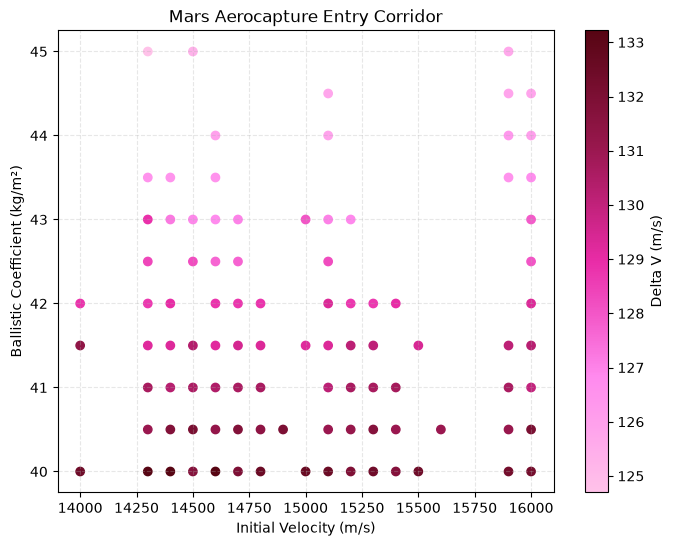

C:\Users\Sophie Kos\AppData\Local\Temp\ipykernel_20260\4137536966.py:84: UserWarning: Adding colorbar to a different Figure <Figure size 800x600 with 3 Axes> than <Figure size 640x480 with 1 Axes> which fig.colorbar is called on.
  cbar = plt.colorbar(scatter)


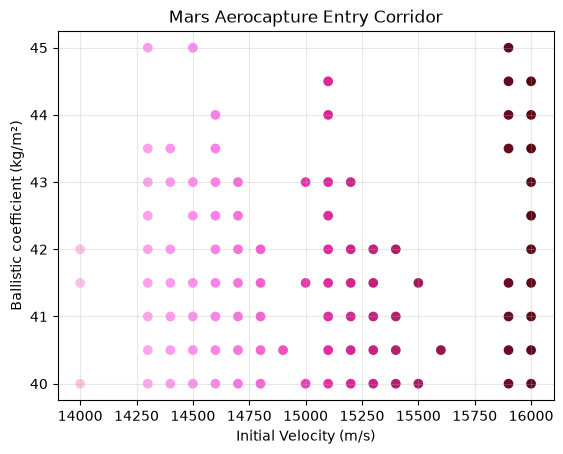

C:\Users\Sophie Kos\AppData\Local\Temp\ipykernel_20260\4137536966.py:102: UserWarning: Adding colorbar to a different Figure <Figure size 800x600 with 4 Axes> than <Figure size 640x480 with 1 Axes> which fig.colorbar is called on.
  cbar = plt.colorbar(scatter)


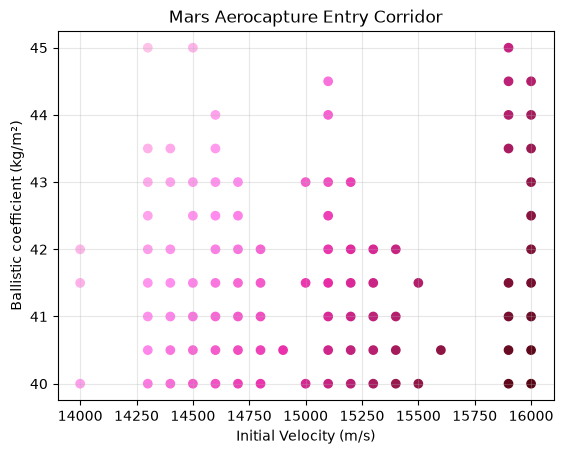

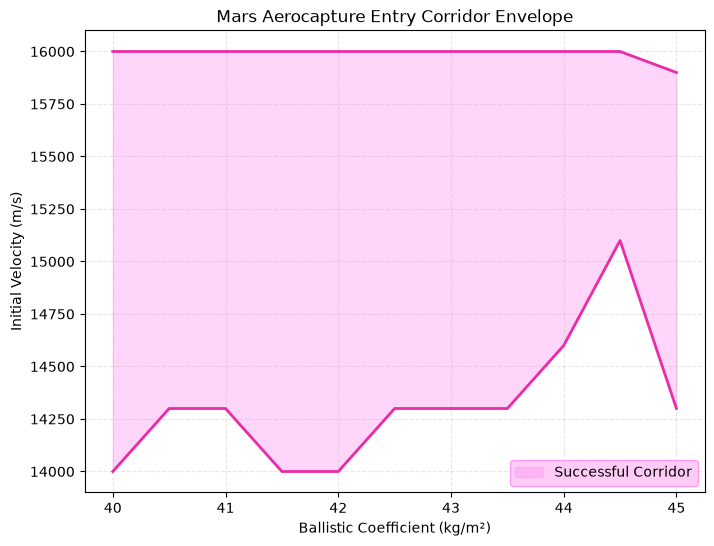

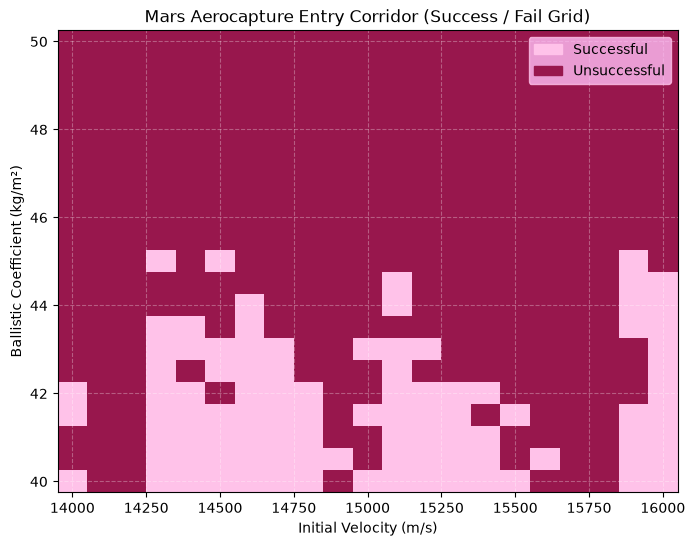

In [ ]:
if __name__ == "__main__":

    velocities = np.linspace(14000, 16000, 21)
    betas = np.linspace(40, 50, 21)

    # Build list of all (beta, velocity) parameter pairs
    param_pairs = [(beta, velocity) for beta in betas for velocity in velocities]

    # Define worker function to handle a single trajectory
    def evaluate_trajectory(params):
        beta, velocity = params
        result = run_aerocapture(beta, velocity)
        is_success = result is not None

        return {
            "beta": beta,
            "velocity": velocity,
            "success": is_success,
            "apoapsis": result["apoapsis_altitude"] if is_success else np.nan,
            "delta_v": result["delta_v"] if is_success else np.nan,
            "exit_velocity": result["velocity_exit"] if is_success else np.nan,
            "max_g_load": result["g_load"] if is_success else np.nan,
            "max_total_heat_flux": result["total_heat"] if is_success else np.nan,
            "max_rad_heat_flux": result["radiative_heat"] if is_success else np.nan,
            "max_conv_heat_flux": result["convective_heat"] if is_success else np.nan
        }

    print(f"Starting parallel sweep for {len(param_pairs)} runs across all CPU cores...")

    # n_jobs=-1 automatically uses ALL available CPU cores
    # verbose=10 prints progress updates as jobs complete
    results = Parallel(n_jobs=-1, verbose=10)(
        delayed(evaluate_trajectory)(p) for p in param_pairs
    )

    # Generate a timestamp
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    output_filename = f"aerocapture_beta_velocity_sweep_{timestamp}.csv"

    # Save to CSV
    df = pd.DataFrame(results)
    df.to_csv(output_filename, index=False)
    print(f"\nResults saved to {output_filename}!")

    # Filter dataframe for successful runs only (used in Plots 1 & 2)
    df_success = df[df["success"] == True]

    # ============================================================
    # PLOT 1: HEAT BAR PLOT WITH DELTA V
    # ============================================================

    #Custom Color Gradient
    cmap_colors = LinearSegmentedColormap.from_list(
            "Gradient",
            ["#FFC2E9", "#FF8AEE", "#E92CA7", "#98174D", "#570513"] # Soft Pink -> Hot Pink -> Purple -> Dark Purple
        )
    
    plt.figure(figsize=(8, 6))
    
    scatter = plt.scatter(
        df_success["velocity"],
        df_success["beta"],
        c=df_success["delta_v"],
        cmap=cmap_colors)
    
    cbar = plt.colorbar(scatter)
    cbar.set_label("Delta V (m/s)", color="black")
    plt.xlabel("Initial Velocity (m/s)")
    plt.ylabel("Ballistic Coefficient (kg/m²)")
    plt.title("Mars Aerocapture Entry Corridor", fontsize=12, color="black")
    plt.grid(True, linestyle="--", alpha=0.3)
    plt.show()

    # ============================================================
    # PLOT 2: HEAT BAR PLOT WITH HEAT
    # ============================================================
     
    scatter = plt.scatter(
        df_success["velocity"],
        df_success["beta"],
        c=df_success["max_total_heat_flux"],
        cmap=cmap_colors)

    cbar = plt.colorbar(scatter)
    cbar.set_label("Max Total Heat Flux (W/m²)", color="black")
    plt.xlabel("Initial Velocity (m/s)")
    plt.ylabel("Ballistic coefficient (kg/m²)")
    plt.title("Mars Aerocapture Entry Corridor", fontsize=12, color="black")
    plt.grid(alpha=0.3)
    plt.show()

    # ============================================================
    # PLOT 3: HEAT BAR PLOT WITH G-LOAD
    # ============================================================
    
    scatter = plt.scatter(
            df_success["velocity"],
            df_success["beta"],
            c=df_success["max_g_load"],
            cmap=cmap_colors)
    
    cbar = plt.colorbar(scatter)
    cbar.set_label("Max G Load (Gs)", color="black")
    plt.xlabel("Initial Velocity (m/s)")
    plt.ylabel("Ballistic coefficient (kg/m²)")
    plt.title("Mars Aerocapture Entry Corridor", fontsize=12, color="black")
    plt.grid(alpha=0.3)
    plt.show()

    # ============================================================
    # PLOT 4: SHADED CORRIDOR
    # ============================================================

    corridor = df_success.groupby("beta")["velocity"].agg(["min", "max"]).reset_index()

    plt.figure(figsize=(8, 6))

    # Pink filled region
    plt.fill_between(
        corridor["beta"],
        corridor["min"],
        corridor["max"],
        alpha=0.35,
        color="#FF8AEE",
        label="Successful Corridor"
    )

    # Limit lines
    plt.plot(
        corridor["beta"],
        corridor["min"],
        color="#E92CA7",
        linewidth=2,
    )

    plt.plot(
        corridor["beta"],
        corridor["max"],
        color="#E92CA7",
        linewidth=2,
    )

    plt.xlabel("Ballistic Coefficient (kg/m²)")
    plt.ylabel("Initial Velocity (m/s)")
    plt.title("Mars Aerocapture Entry Corridor Envelope", fontsize=12, color="black")

    plt.grid(True, linestyle="--", alpha=0.3)
    plt.legend(frameon=True, facecolor="#FFBFF6", edgecolor="#FF8AEE")
    plt.show()

    # ============================================================
    # PLOT 5: SUCCESS PLOT
    # ============================================================

    # Reshape success column into a 2D matrix
    pivot_success = df.pivot(index="beta", columns="velocity", values="success")

    plt.figure(figsize=(8, 6))

    # Binary colormap
    cmap_binary = ListedColormap(["#98174D", "#FFC2E9"])
    mesh = plt.pcolormesh(
        pivot_success.columns,
        pivot_success.index,
        pivot_success.values,
        cmap=cmap_binary,
        shading="nearest"
    )
    
    # Custom legend
    purple_patch = mpatches.Patch(color="#98174D", label="Unsuccessful")
    pink_patch = mpatches.Patch(color="#FFC2E9", label="Successful")
    plt.legend(handles=[pink_patch, purple_patch], loc="upper right", frameon=True, facecolor="#FFBFF6", edgecolor="#FFC2E9")

    plt.xlabel("Initial Velocity (m/s)")
    plt.ylabel("Ballistic Coefficient (kg/m²)")
    plt.title("Mars Aerocapture Entry Corridor (Success / Fail Grid)", fontsize=12, color="black")
    plt.grid(True, color="white", linestyle="--", alpha=0.3)
    plt.show()